In [1]:
## Import important libraries
import os
import re
import json
import string
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.sentiment import SentimentIntensityAnalyzer

# Machine Learning libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.utils import shuffle
from sklearn.manifold import TSNE
from sklearn.preprocessing import Normalizer, StandardScaler, OneHotEncoder

# Visualization libraries
from IPython.display import display

In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\amrit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\amrit\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\amrit\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\amrit\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

In [3]:
### PREPROCESSING ### 

### LOAD AND MERGE REDDIT POSTS AND COMMENTS ###

# Set paths for data
posts_path = r"C:\Users\amrit\GitHub\30100project_individual\PostsMay15_May16"
comments_path = r"C:\Users\amrit\GitHub\30100project_individual\commentsMay15_May16"

# List of all post and comment JSON files
json_files_posts = [f"RS-2015-{str(i).zfill(2)}_subreddit.json" for i in range(5, 13)] + [f"RS-2016-{str(i).zfill(2)}_subreddit.json" for i in range(1, 6)]
json_files_comments = [f"RC-2015-{str(i).zfill(2)}_subreddit.json" for i in range(5, 13)] + [f"RC-2016-{str(i).zfill(2)}_subreddit.json" for i in range(1, 6)]

In [4]:
def load_json_data(folder_path, file_list, columns_to_keep, text_column):
    """
    Loads JSON files into a DataFrame, filters out deleted/removed content, and removes bot accounts.
    """
    data = []
    
    for file in file_list:
        file_path = os.path.join(folder_path, file)
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    data.append(json.loads(line))
                except json.JSONDecodeError:
                    continue  # Skip malformed lines
    
    # Create DataFrame
    df = pd.DataFrame(data)

    # Ensure necessary columns exist before filtering
    if not all(col in df.columns for col in columns_to_keep):
        raise ValueError("Missing expected columns in the dataset")
    
    df = df[columns_to_keep]  # Keep only relevant columns

    # Convert timestamps to datetime format
    df['created_utc'] = pd.to_datetime(df['created_utc'], unit='s')

    # Remove deleted/empty content
    if text_column in df.columns:
        df = df[df[text_column].notna() & ~df[text_column].isin(['[deleted]', '[removed]'])]

    # Remove bot accounts
    bot_keywords = ["AutoModerator", "Moderator", "bot", "AutoMod"]
    if "author" in df.columns:
        df = df[~df["author"].str.contains("|".join(bot_keywords), na=False, case=False)]

    return df


In [5]:
# Load posts and comments
df_posts = load_json_data(posts_path, json_files_posts, ['title', 'selftext', 'score', 'num_comments', 'created_utc', 'author'], 'selftext')
df_comments = load_json_data(comments_path, json_files_comments, ['body', 'score', 'created_utc', 'author'], 'body')

# Merge title and selftext into one field for posts
df_posts['full_text'] = df_posts['title'] + ' ' + df_posts['selftext']
df_posts.drop(columns=['title', 'selftext'], inplace=True)
df_comments.rename(columns={'body': 'full_text'}, inplace=True)

# Add source column
df_posts['source'] = 'post'
df_comments['source'] = 'comment'

# Concatenate posts and comments
df = pd.concat([df_posts, df_comments], ignore_index=True)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\amrit\\GitHub\\30100project_individual\\PostsMay15_May16\\RS-2015-05_subreddit.json'

In [ ]:
### TEXT CLEANING FUNCTION ###

def clean_text(text):
    """Cleans text by removing URLs, punctuation, stopwords, and lemmatizing words."""
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs, digits, and punctuation
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Tokenize
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    
    # Remove stopwords and unwanted words
    tokens = [word for word in tokens if word not in stop_words and word not in ["nan", "ill", "im", "i'm"]]
    
    # Lemmatization with POS tagging
    lemmatizer = WordNetLemmatizer()
    
    def get_pos_tag(word):
        tag = pos_tag([word])[0][1]
        if tag.startswith('N'):
            return 'n'
        elif tag.startswith('V'):
            return 'v'
        elif tag.startswith('J'):
            return 'a'
        elif tag.startswith('R'):
            return 'r'
        else:
            return 'n'
    
    tokens = [lemmatizer.lemmatize(word, get_pos_tag(word)) for word in tokens]
    
    return " ".join(tokens)

In [ ]:
# Apply cleaning to full_text
df['cleaned_text'] = df['full_text'].apply(clean_text)

df.drop(columns=['full_text'], inplace=True)

### SAVE CLEANED DATA ###
cleaned_file_path = os.path.join(posts_path, "cleaned_reddit_data.csv")
df.to_csv(cleaned_file_path, index=False)

# Display first few rows of cleaned dataset
print("Processed and cleaned Reddit data:")
print(df.head())

Processed and cleaned Reddit data:
   score  num_comments         created_utc          author source  \
0      5           1.0 2015-05-01 00:57:43        FercPolo   post   
1      9          15.0 2015-05-01 03:13:16         schlunt   post   
2      2           7.0 2015-05-01 03:36:45  JohnnyRyeBread   post   
3      5           3.0 2015-05-01 14:43:58      bsmboi1017   post   
4      1           2.0 2015-05-01 15:23:26        spidey39   post   

                                        cleaned_text  
0            hows iwsb today imagine aapl trade kill  
1                                               hype  
2  tsla anyone play overarch theme sub historical...  
3  dgaz nat gas dgaz still today beside correctio...  
4                                        short share  


NOW:

Function: word_frequency_analysis(df, text_column, top_n=20)

Description:
This function analyzes the frequency of words appearing in a specified text column of a given DataFrame. 
It tokenizes text, removes punctuation, and counts word occurrences to identify the most common words.

Parameters:
- df (pd.DataFrame): The DataFrame containing the text data.
- text_column (str): The name of the column containing cleaned text.
- top_n (int, default=20): The number of most common words to return.

Returns:
- dict: A dictionary of the top N most frequent words along with their occurrence counts.

Usage Example:
top_words = word_frequency_analysis(df, "cleaned_text", top_n=50)


In [ ]:
# Function to remove specific words from cleaned text
def remove_custom_words(df, text_column, words_to_remove):
    """
    Removes specified words from the text column of a DataFrame.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the text data.
    text_column (str): The name of the column containing cleaned text.
    words_to_remove (list): List of words to be removed from the text.

    Returns:
    pd.DataFrame: The DataFrame with the specified words removed from the text column.
    """
    words_pattern = r'\b(' + '|'.join(re.escape(word) for word in words_to_remove) + r')\b'
    
    df[text_column] = df[text_column].str.replace(words_pattern, '', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()
    
    return df

# Define words to remove
custom_words = ["thanks", "like", "go"]

# Apply the function to remove words from 'cleaned_text'
df = remove_custom_words(df, "cleaned_text", custom_words)

In [ ]:
### ### EXPLORATORY DATA ANALYSIS (EDA) ###

In [ ]:
def word_frequency_analysis(df, text_column, top_n=20):
    """
    Analyzes the frequency of words in the specified text column of a DataFrame.
    
    Parameters:
    df (pd.DataFrame): The DataFrame containing the text data.
    text_column (str): The name of the column containing cleaned text.
    top_n (int): The number of most common words to return.
    
    Returns:
    dict: A dictionary of the top N most common words with their frequencies.
    """
    all_words = []
    for text in df[text_column].dropna():
        words = re.findall(r'\b\w+\b', text.lower())  # Extract words ignoring punctuation
        all_words.extend(words)
    
    word_counts = Counter(all_words)  # Count occurrences of each word
    return word_counts.most_common(top_n)

# Run frequency analysis on the cleaned_text column
top_words = word_frequency_analysis(df, "cleaned_text", top_n=20)
print(top_words)

### SAVE CLEANED DATA ###
cleaned_file_path = os.path.join(posts_path, "cleaned_reddit_data.csv")
df.to_csv(cleaned_file_path, index=False)

# Display first few rows of cleaned dataset
print("Processed and cleaned Reddit data:")
print(df.head())

[('get', 46499), ('make', 29178), ('fuck', 28312), ('stock', 25695), ('dont', 25405), ('think', 25058), ('sell', 24079), ('market', 21249), ('buy', 21077), ('money', 20585), ('call', 20533), ('would', 20532), ('day', 20386), ('time', 19750), ('good', 19607), ('see', 19206), ('look', 19134), ('well', 18713), ('put', 18530), ('one', 18449)]
Processed and cleaned Reddit data:
   score  num_comments         created_utc          author source  \
0      5           1.0 2015-05-01 00:57:43        FercPolo   post   
1      9          15.0 2015-05-01 03:13:16         schlunt   post   
2      2           7.0 2015-05-01 03:36:45  JohnnyRyeBread   post   
3      5           3.0 2015-05-01 14:43:58      bsmboi1017   post   
4      1           2.0 2015-05-01 15:23:26        spidey39   post   

                                        cleaned_text  
0            hows iwsb today imagine aapl trade kill  
1                                               hype  
2  tsla anyone play overarch theme sub histo

C:\Users\amrit\AppData\Local\Temp\ipykernel_4964\993415025.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Frequency", y="Word", data=top_words_df, palette="viridis")


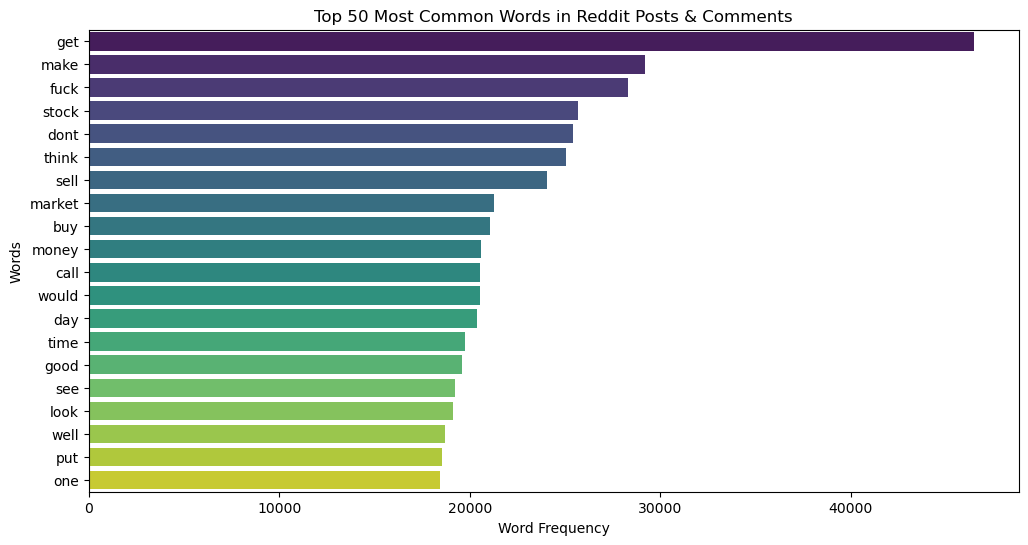

In [ ]:
# DataFrame for visualization
top_words_df = pd.DataFrame(top_words, columns=["Word", "Frequency"])

# Plot bar chart for most common words
plt.figure(figsize=(12, 6))
sns.barplot(x="Frequency", y="Word", data=top_words_df, palette="viridis")
plt.xlabel("Word Frequency")
plt.ylabel("Words")
plt.title("Top 50 Most Common Words in Reddit Posts & Comments")
plt.show()

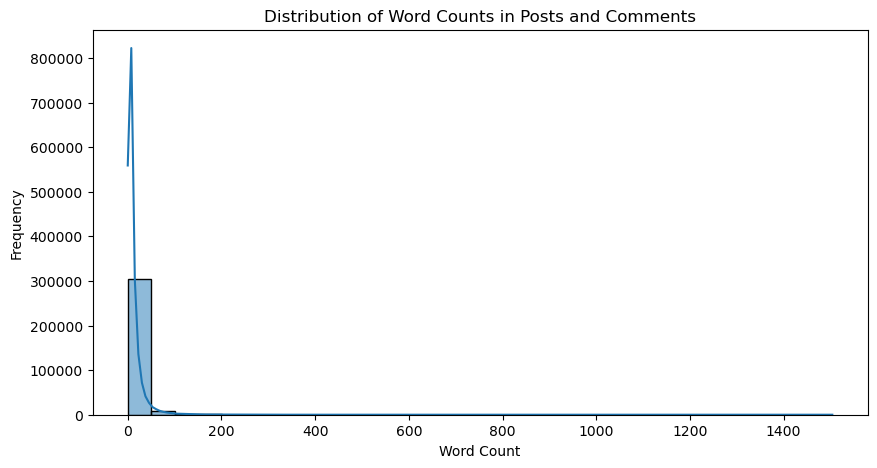

In [ ]:
# 1. WORD COUNT DISTRIBUTION ANALYSIS
# -----------------------------------

# Convert all entries in 'cleaned_text' to string to avoid errors
df['cleaned_text'] = df['cleaned_text'].astype(str)

# Compute word count for each post and comment
df['word_count'] = df['cleaned_text'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)

# Plot histogram to visualize distribution of word counts
plt.figure(figsize=(10,5))
sns.histplot(df['word_count'], bins=30, kde=True)
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Distribution of Word Counts in Posts and Comments")
plt.show()

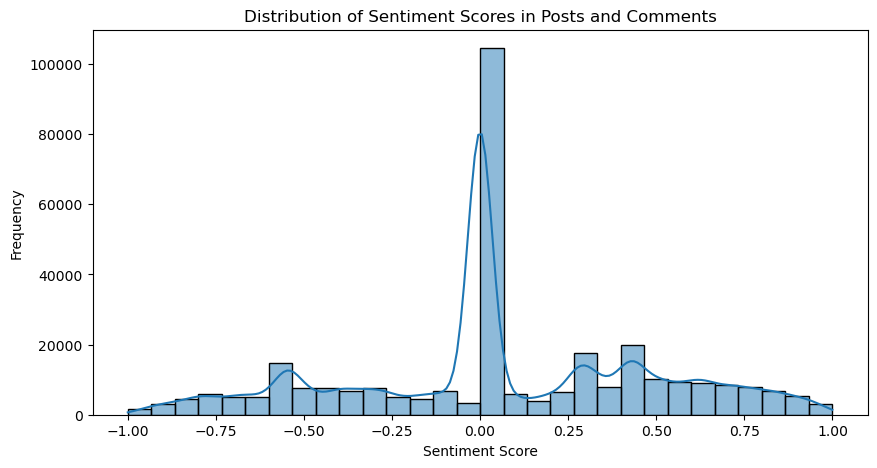

Processed and cleaned Reddit data with EDA:
   score  num_comments         created_utc          author source  \
0      5           1.0 2015-05-01 00:57:43        FercPolo   post   
1      9          15.0 2015-05-01 03:13:16         schlunt   post   
2      2           7.0 2015-05-01 03:36:45  JohnnyRyeBread   post   
3      5           3.0 2015-05-01 14:43:58      bsmboi1017   post   
4      1           2.0 2015-05-01 15:23:26        spidey39   post   

                                        cleaned_text  word_count  \
0            hows iwsb today imagine aapl trade kill           7   
1                                               hype           1   
2  tsla anyone play overarch theme sub historical...          40   
3  dgaz nat gas dgaz still today beside correctio...          16   
4                                        short share           2   

   sentiment_score  
0          -0.6908  
1           0.0000  
2           0.7430  
3           0.4932  
4           0.2960  


In [ ]:
# 2. SENTIMENT ANALYSIS DISTRIBUTION
# ----------------------------------

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    """Computes sentiment polarity score using VADER."""
    return sia.polarity_scores(text)['compound']

# Apply sentiment analysis
df['sentiment_score'] = df['cleaned_text'].apply(get_sentiment)

# Plot sentiment score distribution
plt.figure(figsize=(10,5))
sns.histplot(df['sentiment_score'], bins=30, kde=True)
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.title("Distribution of Sentiment Scores in Posts and Comments")
plt.show()

# Display first few rows of processed dataset
print("Processed and cleaned Reddit data with EDA:")
print(df.head())


TF-IDF Matrix:
       aapl  able  absolutely  access  account  act  action  actual  actually  \
0  0.462574   0.0         0.0     0.0      0.0  0.0     0.0     0.0       0.0   
1  0.000000   0.0         0.0     0.0      0.0  0.0     0.0     0.0       0.0   
2  0.000000   0.0         0.0     0.0      0.0  0.0     0.0     0.0       0.0   
3  0.000000   0.0         0.0     0.0      0.0  0.0     0.0     0.0       0.0   
4  0.000000   0.0         0.0     0.0      0.0  0.0     0.0     0.0       0.0   

   add  ...  yield  yolo  yoloing  youd  youll  youre  youre right  youve  \
0  0.0  ...    0.0   0.0      0.0   0.0    0.0    0.0          0.0    0.0   
1  0.0  ...    0.0   0.0      0.0   0.0    0.0    0.0          0.0    0.0   
2  0.0  ...    0.0   0.0      0.0   0.0    0.0    0.0          0.0    0.0   
3  0.0  ...    0.0   0.0      0.0   0.0    0.0    0.0          0.0    0.0   
4  0.0  ...    0.0   0.0      0.0   0.0    0.0    0.0          0.0    0.0   

   yup  zero  
0  0.0   0.0  
1  0.

C:\Users\amrit\AppData\Local\Temp\ipykernel_4964\341410924.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="TF-IDF Score", y="Word", data=top_tfidf_df, palette="viridis", hue=None, legend=False)


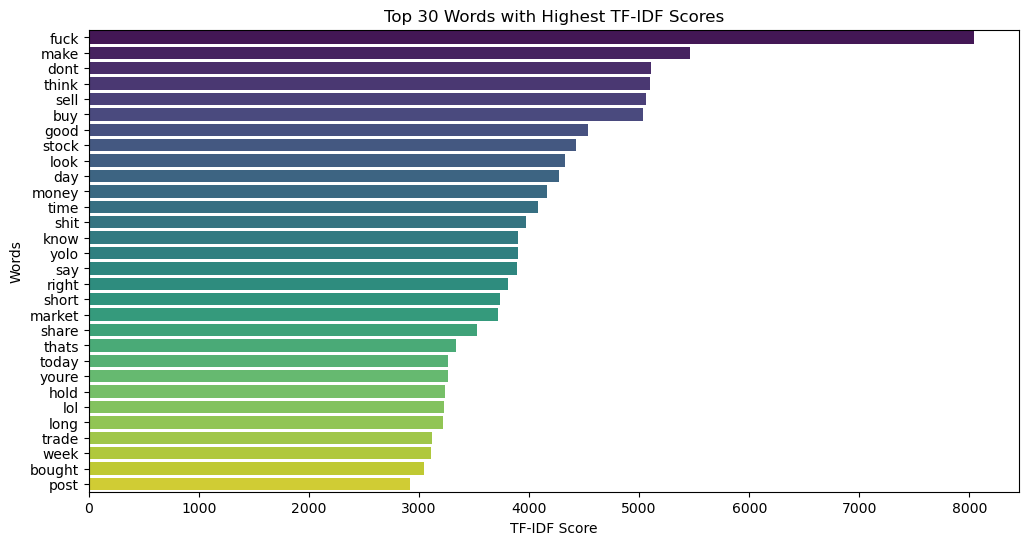

In [ ]:
# 3. FEATURE EXTRACTION USING TF-IDF

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,  # Limit to top 1000 words
    stop_words='english',  # Remove common stopwords
    ngram_range=(1, 2)  # Use unigrams and bigrams for better context understanding
)

# Apply TF-IDF to cleaned_text
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_text'])

# Convert to DataFrame for readability
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(), 
    columns=tfidf_vectorizer.get_feature_names_out()
)

# Display the first few rows
print("TF-IDF Matrix:")
print(tfidf_df.head())

# Find top TF-IDF words for the dataset
word_tfidf_scores = tfidf_matrix.sum(axis=0)  # Sum TF-IDF scores across all documents
word_tfidf_scores = [(word, word_tfidf_scores[0, idx]) for word, idx in tfidf_vectorizer.vocabulary_.items()]
word_tfidf_scores = sorted(word_tfidf_scores, key=lambda x: x[1], reverse=True)

# Convert to DataFrame for visualization
top_tfidf_df = pd.DataFrame(word_tfidf_scores[:30], columns=['Word', 'TF-IDF Score'])

# Plot TF-IDF Scores with updated settings
plt.figure(figsize=(12, 6))
sns.barplot(x="TF-IDF Score", y="Word", data=top_tfidf_df, palette="viridis", hue=None, legend=False)
plt.xlabel("TF-IDF Score")
plt.ylabel("Words")
plt.title("Top 30 Words with Highest TF-IDF Scores")
plt.show()

In [ ]:
### BASIC STATISTICS ###
print("\nSummary Statistics for Numerical Features:")
print(df[['score']].describe())


Summary Statistics for Numerical Features:
               score
count  315232.000000
mean        4.399982
std        15.113845
min      -105.000000
25%         1.000000
50%         2.000000
75%         4.000000
max      2407.000000


In [ ]:
### K-MEANS CLUSTERING ###
cluster_range = range(2, 15)
inertia_values = []

for k in cluster_range:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000, max_iter=50, init='k-means++')
    kmeans.fit(tfidf_matrix)
    inertia_values.append(kmeans.inertia_)

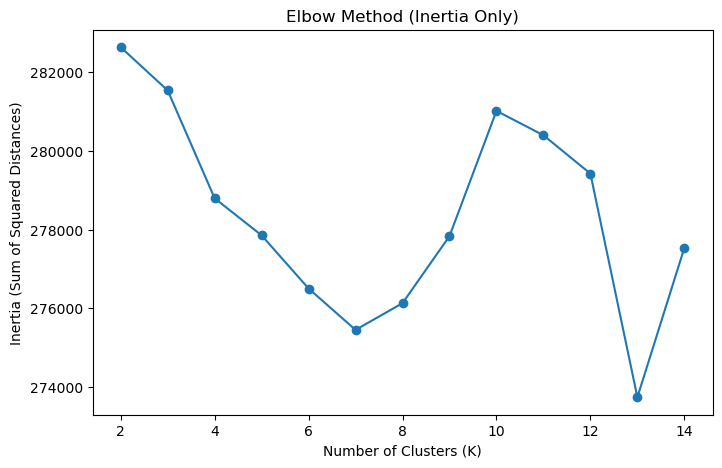

In [ ]:
# Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertia_values, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Sum of Squared Distances)")
plt.title("Elbow Method (Inertia Only)")
plt.show()

c:\Users\amrit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1952: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3584 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
c:\Users\amrit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1952: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3584 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


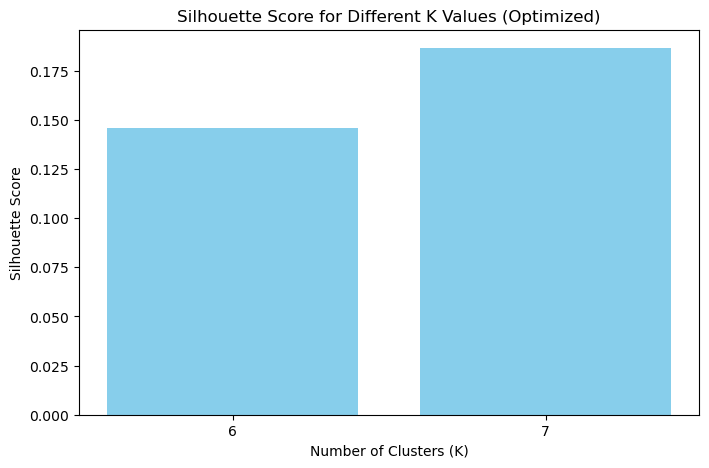

Optimized Silhouette Scores: {6: 0.1459825156500888, 7: 0.1866125083738976}


In [ ]:
# Define the cluster range for evaluation
cluster_range = [6, 7]

# Reduce dimensionality using TruncatedSVD for faster computation
svd = TruncatedSVD(n_components=50, random_state=42)  # Reduce to 50 components for efficiency
tfidf_reduced = svd.fit_transform(tfidf_matrix)

# Sample the data (10,000 points) for silhouette analysis
sample_size = 10000
tfidf_sample, df_sample = shuffle(tfidf_reduced, df, random_state=42, n_samples=sample_size)

# Store silhouette scores
silhouette_values = {}

# Perform MiniBatchKMeans clustering and compute silhouette scores
for k in cluster_range:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000, max_iter=50, init='k-means++')
    labels = kmeans.fit_predict(tfidf_sample)

    # Compute silhouette score
    silhouette_avg = silhouette_score(tfidf_sample, labels)
    silhouette_values[k] = silhouette_avg

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.bar(silhouette_values.keys(), silhouette_values.values(), color='skyblue')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values (Optimized)")
plt.xticks(list(silhouette_values.keys()))
plt.show()

# Print computed silhouette scores
print("Optimized Silhouette Scores:", silhouette_values)


Cluster 0 Top Words:
stock, sell, right, market, option, trade, time, money, day, trading, price, think, look, share, short, lose, good, week, youre, bought

Cluster 1 Top Words:
make, dont, know, money, think, dont know, make money, people, want, dont think, shit, good, youre, look, post, really, trade, fuck, company, need

Cluster 2 Top Words:
buy, sell, dip, share, time, stock, low, high, good, yacht, fuck, buy share, think, dont, want, hold, buy sell, money, price, wait

Cluster 3 Top Words:
fuck, shit, guy, youre, yeah, dont, right, thats, sell, make, faggot, post, yolo, know, money, man, lol, day, today, holy

Cluster 4 Top Words:
say, fuck, youre, thats, dont, make, people, think, id, time, buy, look, didnt, good, know, market, thing, post, shit, stock

Cluster 5 Top Words:
good, yolo, think, look, lol, shit, short, thats, today, hold, share, long, post, bought, week, youre, day, yacht, guy, oil


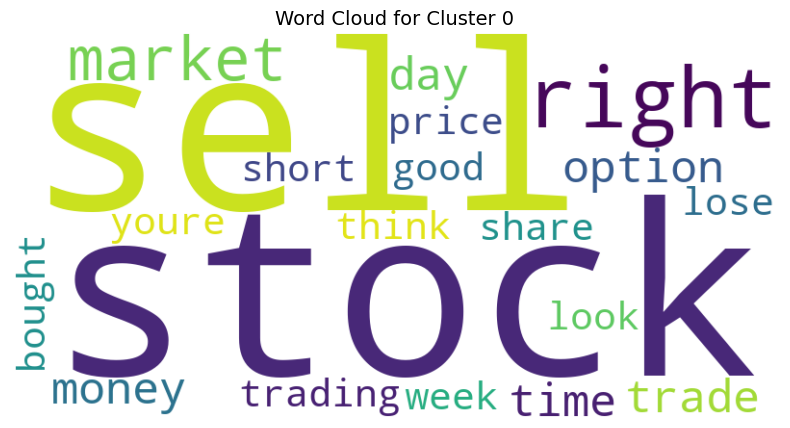

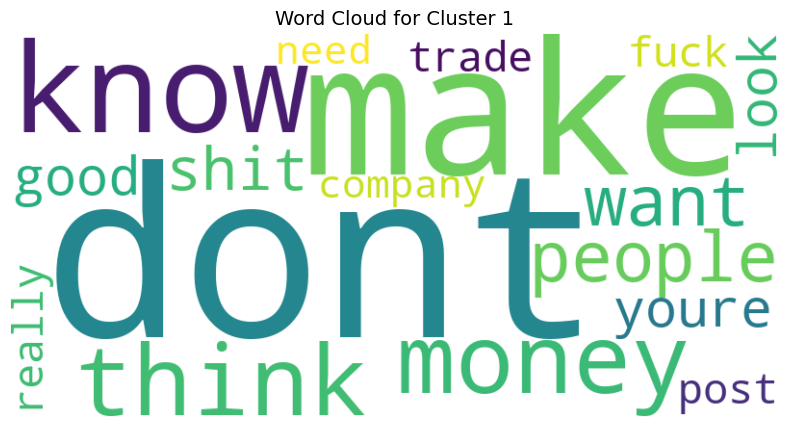

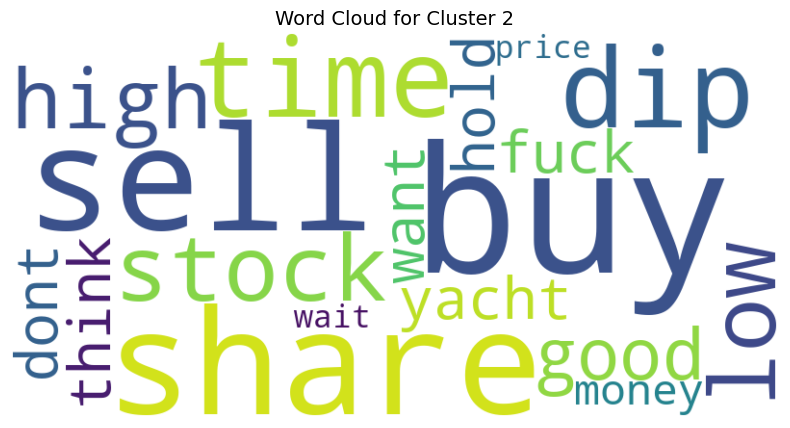

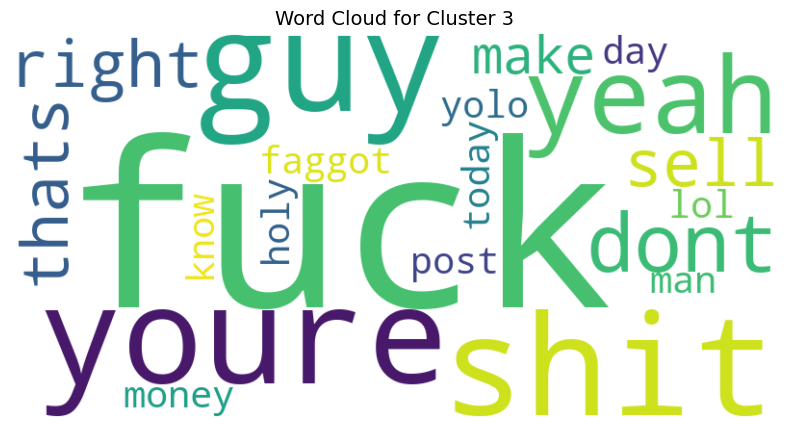

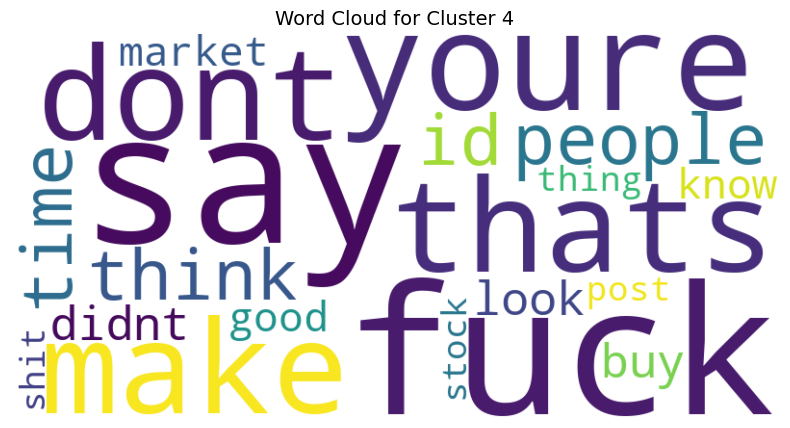

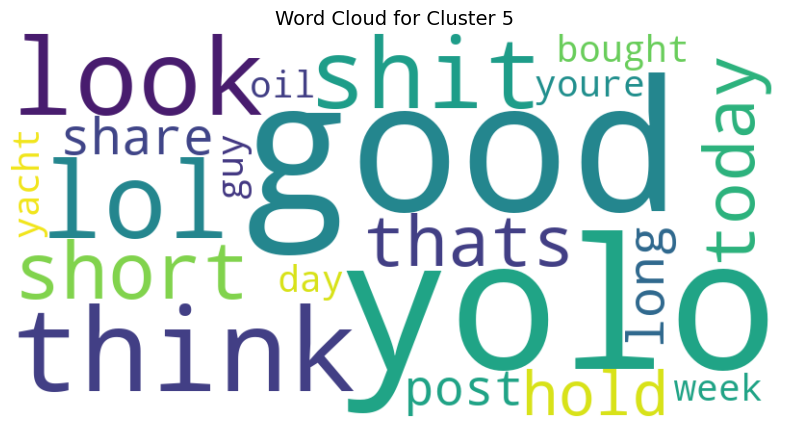

In [ ]:
from wordcloud import WordCloud

# Define the number of clusters based on previous analysis
best_k = 6  # Adjust based on elbow and silhouette analysis

# Fit MiniBatchKMeans on the TF-IDF matrix
kmeans = MiniBatchKMeans(n_clusters=best_k, random_state=42, batch_size=1000, max_iter=50, init='k-means++')
df["cluster"] = kmeans.fit_predict(tfidf_matrix)

# Get feature names from the vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()
n_top_words = 20  # Number of words to display per cluster

# Store cluster top words
cluster_top_words = {}

# Iterate through each cluster to extract top words
for cluster_id in range(best_k):
    # Indices of samples that belong to this cluster
    cluster_indices = np.where(df["cluster"] == cluster_id)[0]

    # Sum up the TF-IDF scores for all words in this cluster
    cluster_tfidf = tfidf_matrix[cluster_indices].sum(axis=0)

    # Convert to array
    cluster_tfidf_array = np.asarray(cluster_tfidf).flatten()

    # Get top N word indices
    top_indices = cluster_tfidf_array.argsort()[::-1][:n_top_words]
    top_terms = [feature_names[i] for i in top_indices]

    # Store top words for visualization
    cluster_top_words[cluster_id] = top_terms

    print(f"\nCluster {cluster_id} Top Words:")
    print(", ".join(top_terms))

# Generate individual word clouds for each cluster
for cluster_id, words in cluster_top_words.items():
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(" ".join(words))
    
    # Create a new figure for each cluster
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.title(f"Word Cloud for Cluster {cluster_id}", fontsize=14)
    plt.axis("off")  # Hide axis
    plt.show()


c:\Users\amrit\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


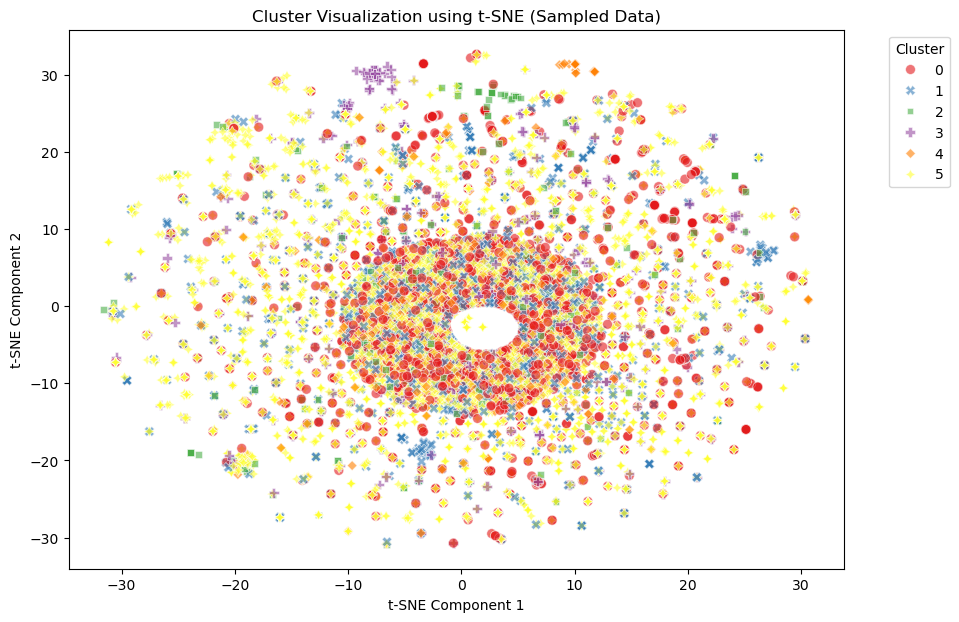

In [ ]:
# Define the number of clusters based on your best K
best_k = 6  # Adjust based on your clustering analysis

# Sample 10,000 points from the dataset
df_sampled = df.sample(n=10000, random_state=42)

# Extract the TF-IDF features of the sampled data
tfidf_sampled = tfidf_matrix[df_sampled.index].toarray()

# Apply t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, perplexity=50, random_state=42, n_iter=500)
tfidf_tsne = tsne.fit_transform(tfidf_sampled)

# Assign the reduced t-SNE components to the DataFrame
df_sampled["tsne_x"] = tfidf_tsne[:, 0]
df_sampled["tsne_y"] = tfidf_tsne[:, 1]

# Ensure cluster labels are present
df_sampled["cluster"] = df.iloc[df_sampled.index]["cluster"]

# Plot t-SNE visualization
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=df_sampled["tsne_x"],
    y=df_sampled["tsne_y"],
    hue=df_sampled["cluster"],
    palette="Set1",  # Different color palette for clarity
    style=df_sampled["cluster"],  # Different markers for better separation
    s=50,  # Size of points
    alpha=0.6  # Transparency for visibility
)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Cluster Visualization using t-SNE (Sampled Data)")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")  # Move legend outside
plt.show()


In [ ]:
# DOUBT - to figure out
# 
# import matplotlib.pyplot as plt
# import pandas as pd

# # 1. Compute daily mean sentiment
# # Assuming your Reddit DataFrame is called `reddit_df`
# # and has columns 'date' (datetime) and 'compound' (VADER score)
# daily_sent = (
#     reddit_df
#     .set_index('date')['compound']
#     .resample('D')
#     .mean()
# )

# # 2. Load or reference your DAX series
# # Assuming your DAX DataFrame is `dax_df` with 'date' and 'Close'
# dax_ts = (
#     dax_df
#     .set_index('date')['Close']
#     .resample('D')
#     .last()
# )

# # 3. Align indices (optional: fill missing days)
# combined = pd.concat([daily_sent, dax_ts], axis=1).dropna()
# combined.columns = ['Avg_Sentiment', 'DAX_Close']

# # 4. Plot on twin axes
# fig, ax1 = plt.subplots(figsize=(12, 5))

# ax1.plot(combined.index, combined['Avg_Sentiment'], color='tab:blue', label='Avg. Daily Sentiment')
# ax1.set_ylabel('Mean VADER Compound', color='tab:blue')
# ax1.tick_params(axis='y', labelcolor='tab:blue')

# ax2 = ax1.twinx()
# ax2.plot(combined.index, combined['DAX_Close'], color='tab:orange', label='DAX Close')
# ax2.set_ylabel('DAX Closing Price', color='tab:orange')
# ax2.tick_params(axis='y', labelcolor='tab:orange')

# plt.title('Daily Average Reddit Sentiment vs. DAX Index')
# ax1.legend(loc='upper left')
# ax2.legend(loc='upper right')
# plt.tight_layout()
# plt.show()
